Import Libraries 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")
print("TensorFlow version:", tf.__version__)

✅ Libraries imported!
TensorFlow version: 2.21.0


Load Dataset

In [2]:
DATASET_PATH = r'C:\Users\hp\Downloads\facerecognition\dataset'
IMG_SIZE = 64

images = []
labels = []

for person in os.listdir(DATASET_PATH):
    person_folder = os.path.join(DATASET_PATH, person)
    if os.path.isdir(person_folder):
        for img_file in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))
                labels.append(person)
            except:
                pass

images = np.array(images)
labels = np.array(labels)

print(f"✅ Total images loaded: {len(images)}")
print(f"✅ Classes: {np.unique(labels)}")
print(f"✅ Image shape: {images[0].shape}")

✅ Total images loaded: 35
✅ Classes: ['Darshni' 'Fazura' 'Nancy_Ajram' 'Raden_Salma' 'Sherlock' 'Siti_Amirah'
 'Tom_Holland']
✅ Image shape: (64, 64, 3)


Load Dataset

In [3]:
DATASET_PATH = r'C:\Users\hp\Downloads\facerecognition\dataset'
IMG_SIZE = 64

images = []
labels = []

for person in os.listdir(DATASET_PATH):
    person_folder = os.path.join(DATASET_PATH, person)
    if os.path.isdir(person_folder):
        for img_file in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_file)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))
                labels.append(person)
            except:
                pass

images = np.array(images)
labels = np.array(labels)

print(f"✅ Total images loaded: {len(images)}")
print(f"✅ Classes: {np.unique(labels)}")
print(f"✅ Image shape: {images[0].shape}")

✅ Total images loaded: 35
✅ Classes: ['Darshni' 'Fazura' 'Nancy_Ajram' 'Raden_Salma' 'Sherlock' 'Siti_Amirah'
 'Tom_Holland']
✅ Image shape: (64, 64, 3)


Visualize Sample Image

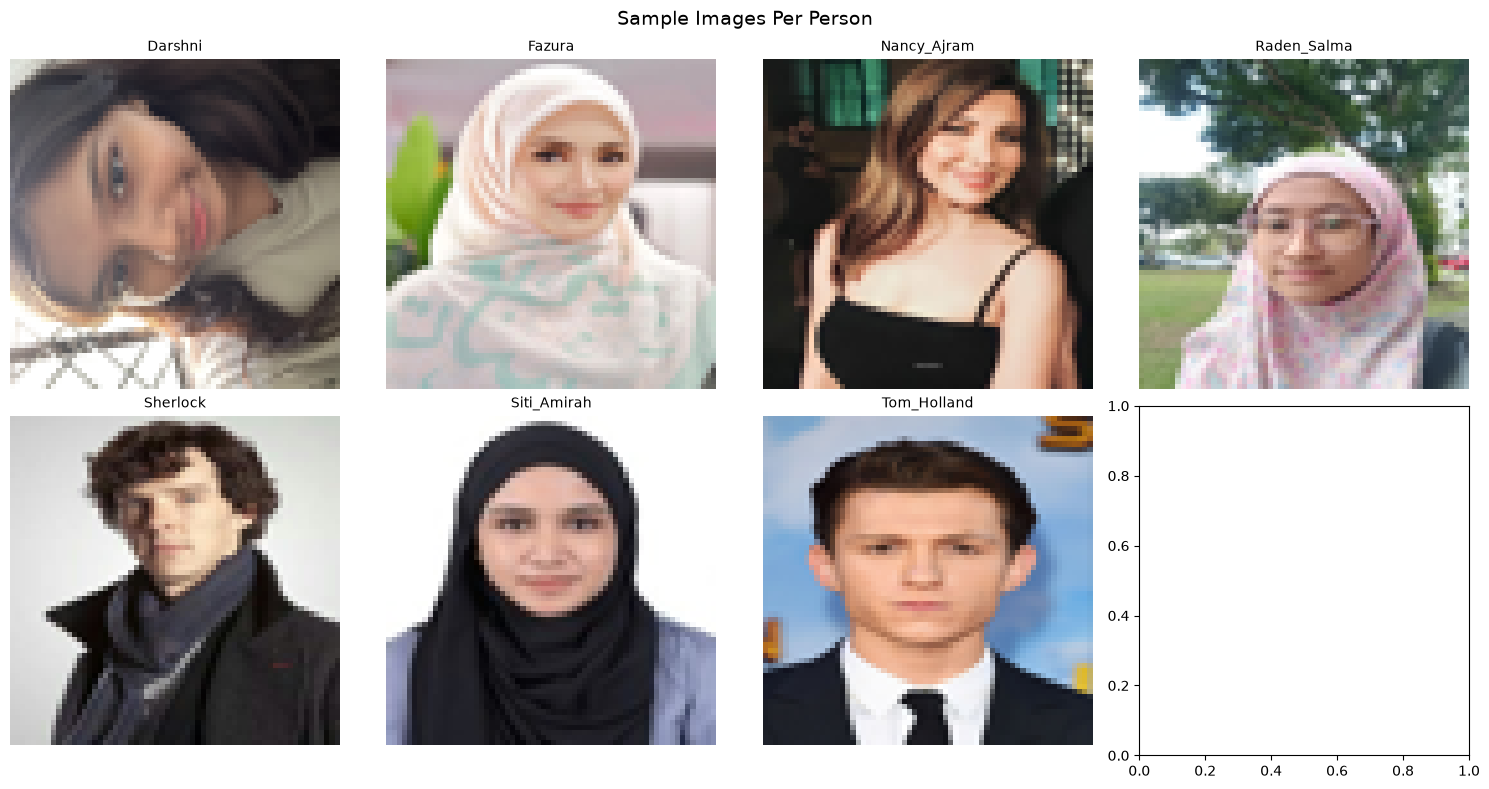

✅ Sample images displayed!


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
unique_labels = np.unique(labels)

for i, ax in enumerate(axes.flat):
    if i < len(unique_labels):
        idx = np.where(labels == unique_labels[i])[0][0]
        ax.imshow(images[idx])
        ax.set_title(unique_labels[i], fontsize=10)
        ax.axis('off')

plt.suptitle('Sample Images Per Person', fontsize=14)
plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

Preprocess & Augment Data

In [5]:
# Normalize
X = images / 255.0

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
num_classes = len(np.unique(y_encoded))
y_categorical = to_categorical(y_encoded, num_classes)

print(f"✅ Number of classes: {num_classes}")
print(f"✅ Classes: {le.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

print(f"\n✅ Train: {len(X_train)} images")
print(f"✅ Validation: {len(X_val)} images")
print(f"✅ Test: {len(X_test)} images")

# Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)
print("\n✅ Augmentation pipeline ready!")

✅ Number of classes: 7
✅ Classes: ['Darshni' 'Fazura' 'Nancy_Ajram' 'Raden_Salma' 'Sherlock' 'Siti_Amirah'
 'Tom_Holland']

✅ Train: 22 images
✅ Validation: 6 images
✅ Test: 7 images

✅ Augmentation pipeline ready!


Build CNN Model

In [6]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,488,359 (17.12 MB)

 Trainable params: 4,486,887 (17.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

Train Model

In [7]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=30,
    validation_data=(X_val, y_val),
    verbose=1
)

print("✅ Training complete!")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 0.1364 - loss: 2.7020 - val_accuracy: 0.1667 - val_loss: 1.9269
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1818 - loss: 2.4396 - val_accuracy: 0.3333 - val_loss: 1.8747
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.1364 - loss: 2.5264 - val_accuracy: 0.3333 - val_loss: 1.8455
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1818 - loss: 2.3964 - val_accuracy: 0.3333 - val_loss: 1.7960
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.0909 - loss: 2.5559 - val_accuracy: 0.3333 - val_loss: 1.7918
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3182 - loss: 2.2690 - val_accuracy: 0.3333 - val_loss: 1.7620
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2273 - loss: 1.9340 - val_accuracy: 0.3333 - val_loss: 1.7551
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2727 - loss: 2.6730 - val_accuracy: 0.3333 - val_loss: 1.75

Plot Training Results 

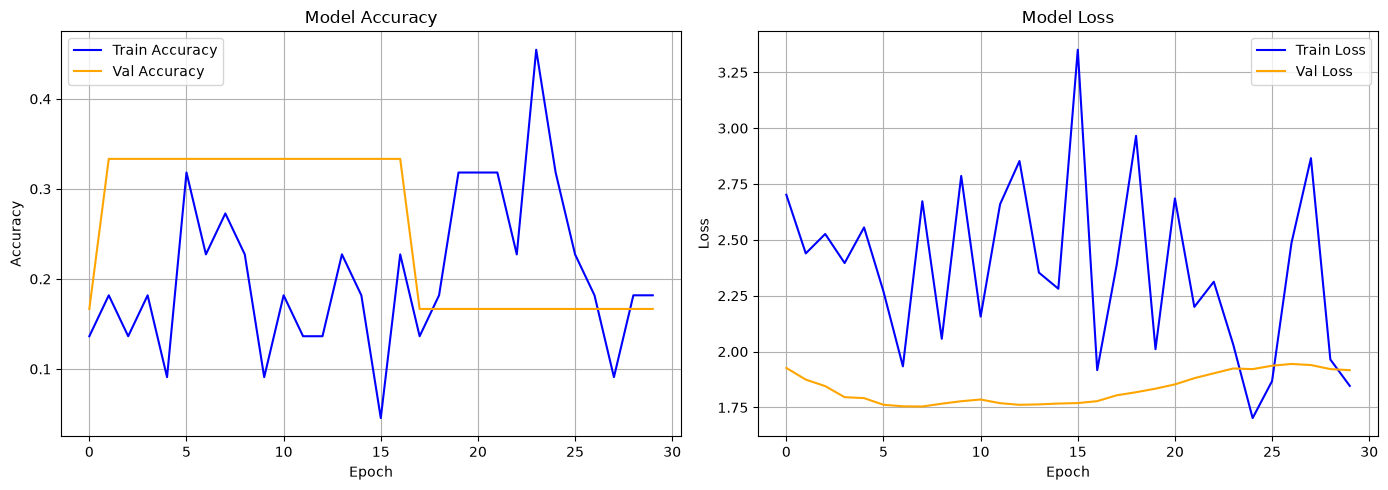

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluate Model

In [9]:
# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

# Classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

✅ Test Accuracy: 14.29%
✅ Test Loss: 2.0614
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

📊 Classification Report:
              precision    recall  f1-score   support

     Darshni       0.00      0.00      0.00         1
      Fazura       0.00      0.00      0.00         1
 Nancy_Ajram       0.00      0.00      0.00         1
 Raden_Salma       0.00      0.00      0.00         1
    Sherlock       0.00      0.00      0.00         1
 Siti_Amirah       0.14      1.00      0.25         1
 Tom_Holland       0.00      0.00      0.00         1

    accuracy                           0.14         7
   macro avg       0.02      0.14      0.04         7
weighted avg       0.02      0.14      0.04         7



Save Model

In [10]:
model.save(r'C:\Users\hp\Downloads\facerecognition\face_recognition_model.h5')
print("✅ Model saved!")

✅ Model saved!
